Bouy data that's at the water intake I think by the 
CHII2 bouy operated by NOAA https://www.ndbc.noaa.gov/station_page.php?station=chii2
Harrison-Dever Crib operated by NOAA - Great Lakes Environmental Research Laboratory https://www.glerl.noaa.gov/metdata/chi/

NOAA CO-OPS Station ID: 9087044
API Docs: https://api.tidesandcurrents.noaa.gov/api/prod/
 
Available products:
  - water_level       (MLLW, ft or meters)
  - water_temperature (°F or °C)
  - wind              (speed, direction, gusts)
  - air_temperature   (°F or °C)
  - air_pressure      (mb)
  - humidity          (%)

Remember I can get metric if I want to, currently has the imperial which I probably should

In [1]:

#general imports
import pandas as pd
import numpy as np

#to check outliers
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

#below are imports for live data
import requests
from datetime import datetime, timedelta
from typing import Literal, Optional
import time


In [2]:
datapath = "data/NOAA_CHII2_bouy/"
#historical data gotten from https://www.ndbc.noaa.gov/station_history.php?station=chii2
raw_2025_df = pd.read_csv(datapath + "chii2h2025.txt", sep=r"\s+", header=0,low_memory=False)
print(raw_2025_df.head(1))
raw_2025_df = raw_2025_df.drop(index=0)
raw_2024_df = pd.read_csv(datapath + "chii2h2024.txt", sep=r"\s+", header=0, low_memory=False).drop(index=0)
raw_2023_df = pd.read_csv(datapath + "chii2h2023.txt", sep=r"\s+", header=0, low_memory=False).drop(index=0)
raw_2022_df = pd.read_csv(datapath + "chii2h2022.txt", sep=r"\s+", header=0, low_memory=False).drop(index=0)
raw_2021_df = pd.read_csv(datapath + "chii2h2021.txt", sep=r"\s+", header=0, low_memory=False).drop(index=0)


   #YY  MM  DD  hh  mm  WDIR WSPD  GST WVHT  DPD  APD   MWD PRES  ATMP  WTMP  \
0  #yr  mo  dy  hr  mn  degT  m/s  m/s    m  sec  sec  degT  hPa  degC  degC   

   DEWP VIS TIDE  
0  degC  mi   ft  


In [3]:
# print(raw_2025_df.dtypes)
# float_2021_df = raw_2021_df.astype(float)
# print(float_2021_df.dtypes)

we can convert all columns to floats succesfully

In [4]:
#combining all the summers into one dataframe:
all_summers_chii2 = pd.concat([raw_2021_df, raw_2022_df, raw_2023_df, raw_2024_df, raw_2025_df]).astype(float)
print(all_summers_chii2.dtypes) 
# confirming that all are labelled as floats

#YY     float64
MM      float64
DD      float64
hh      float64
mm      float64
WDIR    float64
WSPD    float64
GST     float64
WVHT    float64
DPD     float64
APD     float64
MWD     float64
PRES    float64
ATMP    float64
WTMP    float64
DEWP    float64
VIS     float64
TIDE    float64
dtype: object


In [5]:
# This just gives full dataframe as output

# nan_check = np.isnan(all_summers_chii2)
# print(nan_check == True)

#looking to show output only when nan is true: #remember ax-s = 0 is row and axis =1 is columns
nan_df = all_summers_chii2[all_summers_chii2.isna().any(axis=1)]
nan_df
#looks like there are float values for everything
all_summers_chii2.describe()
#columns with a stdev of 0 are WVHT DPD APD MWD PRES WTMP VIS TIDE these are all 99 values and are taken out
chii2_df = all_summers_chii2.copy()
chii2_df = chii2_df.drop(columns=['WVHT','DPD','APD','MWD','PRES','WTMP','VIS','TIDE'])
display(chii2_df.head(3))
chii2_df.describe()


,#YY,MM,DD,hh,mm,WDIR,WSPD,GST,ATMP,DEWP
1,2021.0,1.0,1.0,0.0,0.0,190.0,2.6,3.1,-1.6,-5.4
2,2021.0,1.0,1.0,0.0,10.0,200.0,3.1,3.6,-1.6,-5.4
3,2021.0,1.0,1.0,0.0,20.0,210.0,3.1,3.6,-1.7,-5.1


,#YY,MM,DD,hh,mm,WDIR,WSPD,GST,ATMP,DEWP
count,252192.000000,252192.000000,252192.000000,252192.000000,252192.000000,252192.000000,252192.000000,252192.000000,252192.000000,252192.000000
mean,2023.019632,6.513636,15.735190,11.500408,24.975733,198.263228,7.399358,8.329059,13.261460,9.104790
std,1.408093,3.468210,8.830902,6.921321,17.084187,100.903887,4.014909,4.523088,41.161617,47.713601
min,2021.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-22.900000,-28.600000
25%,2022.000000,4.000000,8.000000,5.000000,10.000000,120.000000,4.600000,5.100000,3.300000,-0.500000
50%,2023.000000,6.000000,16.000000,11.000000,20.000000,200.000000,7.200000,7.700000,11.900000,6.900000
75%,2024.000000,10.000000,23.000000,18.000000,40.000000,280.000000,9.800000,10.800000,20.900000,16.200000
max,2025.000000,12.000000,31.000000,23.000000,50.000000,360.000000,99.000000,99.000000,999.000000,999.000000


Recall these measurements are recorded in 
   #YY  MM  DD  hh  mm  WDIR WSPD  GST  ATMP DEWP 
0  #yr  mo  dy  hr  mn  degT  m/s  m/s  degC degC 
recall this is the site this data was downloaded from (there are multiple places to get it I believe) https://www.ndbc.noaa.gov/station_history.php?station=chii2

recall that these are the column descriptions: https://www.ndbc.noaa.gov/faq/measdes.shtml

Historical files show times in UTC only 

WDIR = Wind direction (the direction the wind is coming from in degrees clockwise from true N) during the same period used for WSPD. See Wind Averaging Methods

WSPD = Wind speed (m/s) averaged over an eight-minute period for buoys and a two-minute period for land stations. Reported Hourly. See Wind Averaging Methods.

GST = Peak 5 or 8 second gust speed (m/s) measured during the eight-minute or two-minute period. The 5 or 8 second period can be determined by payload, See the Sensor Reporting, Sampling, and Accuracy section.

ATMP = Air temperature (Celsius). For sensor heights on buoys, see Hull Descriptions. For sensor heights at C-MAN stations, see C-MAN Sensor Locations

DEWP = Dew point temperature taken at the same height as the air temperature measurement.


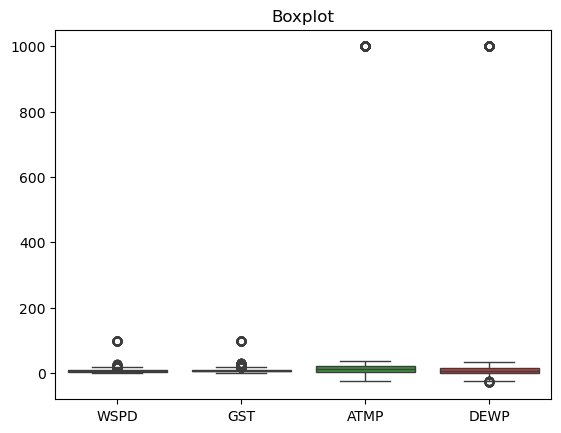

In [6]:
#'WDIR' has no outliers seen via the boxplot, like it is always between 360 and 0 degrees which makes sense that it's capped as it's a 2D measurement. Doesn't mean there is no sensor error though...
sns.boxplot(data=chii2_df[[ 'WSPD', 'GST','ATMP','DEWP']])
plt.title('Boxplot')
plt.show()
#both WSPD and GST have 99.0 readings as outliers, these are likely at the top of the sensor. Hurricanes get sindspeeds up to 230 m/s
#it's not unreasonable that these are just speeds that exceeded sensor ability, so we'll keep them for now



In [7]:
#airtemp outliers are definitely wrong, there are 410 of them and the other columns look normal:
# atmp_nan_df = chii2_df[chii2_df['ATMP'] == 999.00]
# # display(atmp_nan_df)
# print(atmp_nan_df.describe())

# dewp_nan_df = chii2_df[chii2_df['DEWP'] == 999.0]
# display(dewp_nan_df)
# print(dewp_nan_df.describe())

#total number of rows for this is dataset is 252192 so the 410 and 555 rows is 0.15 % and 0.22% of the dataset, should be safe to omit?
chii2_df = chii2_df[(chii2_df['ATMP'] != 999.0) & (chii2_df['DEWP'] != 999.0)]
chii2_df.describe()


,#YY,MM,DD,hh,mm,WDIR,WSPD,GST,ATMP,DEWP
count,251255.000000,251255.000000,251255.000000,251255.000000,251255.000000,251255.000000,251255.000000,251255.000000,251255.000000,251255.000000
mean,2023.020354,6.518891,15.721610,11.503536,24.975025,198.123500,7.394260,8.319557,11.653097,6.918979
std,1.407047,3.470553,8.824115,6.918090,17.084147,100.766334,3.972598,4.438106,10.594371,10.759381
min,2021.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-22.900000,-28.600000
25%,2022.000000,4.000000,8.000000,6.000000,10.000000,120.000000,4.600000,5.100000,3.200000,-0.600000
50%,2023.000000,6.000000,16.000000,12.000000,20.000000,200.000000,7.200000,7.700000,11.900000,6.800000
75%,2024.000000,10.000000,23.000000,17.000000,40.000000,280.000000,9.800000,10.800000,20.900000,16.100000
max,2025.000000,12.000000,31.000000,23.000000,50.000000,360.000000,99.000000,99.000000,37.000000,35.000000


# date time conversion

In [8]:
chii2_df['timestamp'] = pd.to_datetime({
    'year':   chii2_df['#YY'].astype(int),
    'month':  chii2_df['MM'].astype(int),
    'day':    chii2_df['DD'].astype(int),
    'hour':   chii2_df['hh'].astype(int),
    'minute': chii2_df['mm'].astype(int),
}, utc=True)
chii2_df['timestamp_central'] = chii2_df['timestamp'].dt.tz_convert('America/Chicago')
chii2_df

,#YY,MM,DD,hh,mm,WDIR,WSPD,GST,ATMP,DEWP,timestamp,timestamp_central
1,2021.0,1.0,1.0,0.0,0.0,190.0,2.6,3.1,-1.6,-5.4,2021-01-01 00:00:00+00:00,2020-12-31 18:00:00-06:00
2,2021.0,1.0,1.0,0.0,10.0,200.0,3.1,3.6,-1.6,-5.4,2021-01-01 00:10:00+00:00,2020-12-31 18:10:00-06:00
3,2021.0,1.0,1.0,0.0,20.0,210.0,3.1,3.6,-1.7,-5.1,2021-01-01 00:20:00+00:00,2020-12-31 18:20:00-06:00
4,2021.0,1.0,1.0,0.0,30.0,220.0,3.1,3.1,-1.7,-5.0,2021-01-01 00:30:00+00:00,2020-12-31 18:30:00-06:00
5,2021.0,1.0,1.0,0.0,40.0,190.0,2.1,2.6,-1.8,-5.1,2021-01-01 00:40:00+00:00,2020-12-31 18:40:00-06:00
...,...,...,...,...,...,...,...,...,...,...,...,...
50668,2025.0,12.0,31.0,23.0,10.0,270.0,9.3,10.3,1.6,0.5,2025-12-31 23:10:00+00:00,2025-12-31 17:10:00-06:00
50669,2025.0,12.0,31.0,23.0,20.0,270.0,8.8,9.8,1.8,0.6,2025-12-31 23:20:00+00:00,2025-12-31 17:20:00-06:00
50670,2025.0,12.0,31.0,23.0,30.0,270.0,9.3,10.8,1.9,0.6,2025-12-31 23:30:00+00:00,2025-12-31 17:30:00-06:00
50671,2025.0,12.0,31.0,23.0,40.0,270.0,9.8,10.3,2.0,0.6,2025-12-31 23:40:00+00:00,2025-12-31 17:40:00-06:00


In [9]:
print('~~~~raw data~~~~')
print(all_summers_chii2.head())
print(all_summers_chii2.shape)
print(all_summers_chii2.dtypes)
print(all_summers_chii2.isna().sum())
print(all_summers_chii2.describe())
print('~~~~prepped data~~~~')
print(chii2_df.head())
print(chii2_df.shape)
print(chii2_df.dtypes)
print(chii2_df.isna().sum())
print(chii2_df.describe())

~~~~raw data~~~~
      #YY   MM   DD   hh    mm   WDIR  WSPD  GST  WVHT   DPD   APD    MWD  \
1  2021.0  1.0  1.0  0.0   0.0  190.0   2.6  3.1  99.0  99.0  99.0  999.0   
2  2021.0  1.0  1.0  0.0  10.0  200.0   3.1  3.6  99.0  99.0  99.0  999.0   
3  2021.0  1.0  1.0  0.0  20.0  210.0   3.1  3.6  99.0  99.0  99.0  999.0   
4  2021.0  1.0  1.0  0.0  30.0  220.0   3.1  3.1  99.0  99.0  99.0  999.0   
5  2021.0  1.0  1.0  0.0  40.0  190.0   2.1  2.6  99.0  99.0  99.0  999.0   

     PRES  ATMP   WTMP  DEWP   VIS  TIDE  
1  9999.0  -1.6  999.0  -5.4  99.0  99.0  
2  9999.0  -1.6  999.0  -5.4  99.0  99.0  
3  9999.0  -1.7  999.0  -5.1  99.0  99.0  
4  9999.0  -1.7  999.0  -5.0  99.0  99.0  
5  9999.0  -1.8  999.0  -5.1  99.0  99.0  
(252192, 18)
#YY     float64
MM      float64
DD      float64
hh      float64
mm      float64
WDIR    float64
WSPD    float64
GST     float64
WVHT    float64
DPD     float64
APD     float64
MWD     float64
PRES    float64
ATMP    float64
WTMP    float64
DEWP    f

In [10]:
# Sentinel checks
print(f"WSPD == 99: {(chii2_df['WSPD'] == 99.0).sum()}")
print(f"GST == 99:  {(chii2_df['GST'] == 99.0).sum()}")

# Calm vs missing
print(f"WSPD == 0:  {(chii2_df['WSPD'] == 0).sum()}")

# Time coverage
print(f"Months present: {sorted(chii2_df['timestamp_central'].dt.month.unique())}")

# Date range
print(f"Range: {chii2_df['timestamp_central'].min()} to {chii2_df['timestamp_central'].max()}")

WSPD == 99: 77
GST == 99:  79
WSPD == 0:  700
Months present: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Range: 2020-12-31 18:00:00-06:00 to 2025-12-31 17:50:00-06:00


In [11]:
import numpy as np

def clean_chii2(df):
    """Replace NOAA sentinel values with NaN. Returns a clean copy."""
    df = df.copy()
    
    # Wind speed sentinels (99.0 = missing)
    df.loc[df['WSPD'] == 99.0, 'WSPD'] = np.nan
    df.loc[df['GST']  == 99.0, 'GST']  = np.nan
    
    # Wind direction: 0 paired with WSPD == 0 is genuine calm (keep)
    # 0 paired with WSPD > 0 is sensor noise (set to NaN)
    bad_wdir = (df['WDIR'] == 0) & (df['WSPD'] > 0)
    df.loc[bad_wdir, 'WDIR'] = np.nan
    
    # ATMP and DEWP look already cleaned (max ~37, ~35) — leave alone
    
    return df

chii2_clean = clean_chii2(chii2_df)

# Verify
print(f"Shape: {chii2_clean.shape}")
print(f"\nNaN counts after cleaning:")
print(chii2_clean[['WSPD', 'GST', 'WDIR', 'ATMP', 'DEWP']].isna().sum())
print(f"\nWSPD range: {chii2_clean['WSPD'].min()} to {chii2_clean['WSPD'].max()}")
print(f"GST range:  {chii2_clean['GST'].min()} to {chii2_clean['GST'].max()}")
print(f"WDIR range: {chii2_clean['WDIR'].min()} to {chii2_clean['WDIR'].max()}")

Shape: (251255, 12)

NaN counts after cleaning:
WSPD    77
GST     79
WDIR     0
ATMP     0
DEWP     0
dtype: int64

WSPD range: 0.0 to 26.8
GST range:  0.0 to 31.4
WDIR range: 0.0 to 360.0


In [12]:
chii2_clean['station_name'] = 'chii2'
chii2_clean['station_lat'] = 41.916000
chii2_clean['station_lon'] = -87.572000
# chii2_clean.columns
chii2_final = chii2_clean[['WDIR', 'WSPD', 'GST','timestamp_central', 'station_name', 'station_lat','station_lon']]
chii2_final.dtypes

WDIR                                         float64
WSPD                                         float64
GST                                          float64
timestamp_central    datetime64[ns, America/Chicago]
station_name                                  object
station_lat                                  float64
station_lon                                  float64
dtype: object

In [13]:
chii2_final
chii2_final.to_parquet("data/prepared_data/chii2_noaa.parquet", index=False)

In [14]:
# chii2_df.plot(x="timestamp", y=["DEWP","ATMP"], figsize=(12, 4),
#         title="dew point and air temp over time",
#         ylabel="temp in C", legend=True)
# plt.tight_layout()
# plt.show()

# This data is ready to be combinded, may need some adjustments to be directly compared with other data

to check - time, this one is in UTC and is recorded ever ten minutes, and make sure to check the other metrics for how data was recorded. The timestamp is in central time.

I'm going to implement a feature naming convention now: 
 Feature naming convention for this project:

     {source}_{variable}_{operation}_{window}

 - source:    where the data came from (coc, usgs, beach, season, etc.)

 - variable:  what's being measured (precip, temp, wind, etc.)

 - operation: how it was aggregated (sum, max, mean, count, lag)
 
 - window:    over what time period (24h, 7d, 6h)

 Examples:

   coc_precip_sum_24h     -> sum of COC precip over 24h before sample

   coc_precip_max_6h      -> max single-bucket COC precip in last 6h

   usgs_precip_sum_7d     -> sum of USGS precip over 7 days

   season_sin_doy         -> sin of day-of-year (no source/window needed)

 Rule: if you change ONE thing about a feature, only ONE slot in the
 name should change. This makes filtering by prefix easy.

# Trying to use API (failed)

In [15]:
# #constants for pulling data
# STATION_ID   = "9087044"          # NOAA CO-OPS station for CHII2
# BASE_URL     = "https://api.tidesandcurrents.noaa.gov/api/prod/datagetter"
# STATION_NAME = "Harrison-Dever Crib, Chicago, IL"
# #products are water_level, water_temperature, wind, air_temperature, air_pressure, and humidity
# Product = Literal[
#     "water_level",
#     "water_temperature",
#     "wind",
#     "air_temperature",
#     "air_pressure",
#     "humidity",
# ]
 
# Units   = Literal["english", "metric"]   # english = ft/°F, metric = m/°C
# Datum   = Literal["MLLW", "MSL", "NAVD", "LWI", "HWI", "MTL", "MLW", "MHW"]


In [16]:
# #uses NOAA Tides & Currents API
# def _fetch(params: dict) -> pd.DataFrame:

#     # 1. Add the station ID and formatting options that every request needs
#     params.update({
#         "station":   STATION_ID,    # "9087044" — the CHII2 buoy
#         "format":    "json",        # ask for JSON back, not XML
#         "time_zone": "lst_ldt",     # return times in Chicago local time
#     })

#     # 2. Send the HTTP GET request to NOAA
#     r = requests.get(BASE_URL, params=params, timeout=15)
#     r.raise_for_status()  # crash immediately if NOAA returns a 4xx/5xx error

#     # 3. Parse the JSON response body
#     body = r.json()

#     # 4. NOAA sometimes returns a 200 OK but puts an error message in the body
#     if "error" in body:
#         raise ValueError(f"NOAA API error: {body['error']['message']}")

#     # 5. Pull out the actual data rows (key is "data" or "predictions" depending on product)
#     data = body.get("data") or body.get("predictions", [])
#     if not data:
#         raise ValueError("No data returned for the requested range/product.")

#     # 6. Convert the list of dicts into a DataFrame and rename cryptic columns
#     df = pd.DataFrame(data)
#     df.rename(columns={"t": "datetime", "v": "value", "s": "sigma",
#                         "f": "flags",   "q": "quality"}, inplace=True)
#     # NOAA uses single-letter column names in their JSON ("t" for time, "v" for value, etc.)

#     # 7. Set datetime as the index so you can slice by time easily
#     if "datetime" in df.columns:
#         df["datetime"] = pd.to_datetime(df["datetime"])
#         df.set_index("datetime", inplace=True)

#     # 8. Convert value columns from strings to numbers
#     for col in ["value", "sigma", "speed", "direction", "gust"]:
#         if col in df.columns:
#             df[col] = pd.to_numeric(df[col], errors="coerce")

#     return df


In [17]:
# #to get historical data
# def get_historical(
#     product  = "water_level",    # what to fetch: water_level, water_temperature, wind, etc.
#     start    = None,             # "20210501" or "2021-05-01" — defaults to 7 days ago
#     end      = None,             # same format — defaults to right now
#     days_back = 7,               # only used when start/end are left blank
#     units    = "english",        # english = ft/°F, metric = m/°C
#     datum    = "MLLW",           # water level reference point (only matters for water_level)
#     interval = "h",              # "h" = hourly averages, "6" = raw 6-minute readings
# ):
#     # --- Figure out the date range ---
#     # If no end date given, use right now
#     end_dt   = pd.to_datetime(end)   if end   else datetime.now()
#     # If no start date given, count backwards from end
#     start_dt = pd.to_datetime(start) if start else end_dt - timedelta(days=days_back)

#     # --- Build the request ---
#     # remember NOAA requires dates as "YYYYMMDD HH:MM" strings — NOT integers, NOT timestamps
#     fmt = "%Y%m%d %H:%M"
#     params = {
#         "product":    product,
#         "begin_date": start_dt.strftime(fmt),   # e.g. "20210501 00:00"
#         "end_date":   end_dt.strftime(fmt),      # e.g. "20210930 00:00"
#         "units":      units,
#         "application": "chii2_fetcher",
#         "interval":   interval,
#     }

#     # datum only applies to water_level — other products don't need it
#     if product == "water_level":
#         params["datum"] = datum

#     # --- Send request and return ---
#     return _fetch(params)


In [18]:
# # Explicit date range
# df = get_historical("water_temperature", start="20250501", end="20250930")

# Last 30 days without specifying dates
# df = get_historical("wind", days_back=30)


In [19]:
# def get_realtime(product="water_level", units="english", datum="MLLW"):
#     """Fetch the last 2 days of readings from the CHII2 buoy."""
#     params = {
#         "product": product,
#         "date": "recent",   # NOAA built-in keyword for last 2 days
#         "units": units,
#         "application": "chii2_fetcher",
#     }
#     if product == "water_level":
#         params["datum"] = datum
#     return _fetch(params)


# def get_latest_reading(product="water_level", units="english", datum="MLLW"):
#     """Return only the single most recent observation as a plain dict."""
#     df = get_realtime(product, units, datum)
#     last = df.iloc[-1]   # last row = most recent timestamp
#     return {
#         "datetime": last.name,
#         "value":    last["value"],
#         "product":  product,
#         "units":    units,
#     }
